# GISLR — Landmark Importance via Custom DNN / LSTM / GRU

**What this notebook does.** Trains three custom architectures — a memory-free
per-frame DNN, a causal LSTM, a causal GRU — on **all 543** MediaPipe Holistic
landmarks (no subset), using an engineered per-frame feature pipeline
(translation/scale-invariant position, velocity, acceleration, speed, plus a
small inter-landmark relational block) instead of raw xyz. All three
architectures share **one** learned per-landmark attention gate as their first
layer — the notebook's primary landmark-importance signal (§6). The same gate
sits in front of every architecture, so its values are directly comparable
*across* architectures, unlike reverse-engineering importance from each
architecture's own internal weight shapes (a recurrent input-to-hidden matrix
mixes every landmark together and has no per-landmark structure to read a
weight off of otherwise).

**Pipeline stage vs. diagnostic.** A parallel, self-contained TRAINING stage —
the same relationship to `gislr.1.models.training.ipynb` that
`gislr.1.models.firstplace.ipynb` has: its own feature pipeline
(`sb.recognize.interp.features`), its own models
(`sb.recognize.interp.models`), its own training loop
(`sb.recognize.interp.train`), its own config
(`experiments/recognition/configs/gislr.landmark-importance.json`).
Deliberately **not** wired into `sb.recognize.architectures.ARCHS`,
`sb.recognize.train`, or `registry/` — full-543 landmarks + engineered
features + rotating k-fold CV don't fit that contract (fixed subset, fixed
single split, one registry entry per run), and this is a one-off
interpretability experiment rather than a leaderboard entry. It still reads
the same canonical GISLR split/label map, so the final test-set numbers below
mean the same thing as every other number in this repo, even though no run
from here is written to `registry/`. See `sb.recognize.interp`'s module
docstring for the full rationale.

**Validation scheme ("trained on all samples").** Stratified 5-fold CV
*within* `GISLR_Stratified`'s `train.csv` (seeded, §2) — every training video
serves as validation in exactly one fold, so the out-of-fold (OOF) predictions
collected in §4 cover the **entire** training set without ever validating a
model on data it was trained on. A separate **final** model per architecture
is then fit on all of `train.csv` (§5 — a small 5% internal carve-out drives
early stopping/LR only, and never contributes to a reported metric) and
evaluated **exactly once** on the untouched canonical `test.csv` (§6). "Test
accuracy" anywhere in this notebook always means that single held-out
evaluation, never a fold's validation score.

**Artifact table** (all under `data/cache/gislr/interp_runs/`):

| path | content |
|---|---|
| `folds.json` | the seeded 5-fold assignment (row index → fold) |
| `<arch>/fold<k>.pt` | resumable checkpoint for one (architecture, fold) |
| `<arch>/final.pt` | resumable checkpoint for the final full-train fit |
| `<arch>/oof_predictions.npz` | OOF predicted probabilities + labels, full `train.csv` coverage |
| `<arch>/test_predictions.npz` | the final model's single pass over `test.csv` |
| `<arch>/assets/landmark_ranking.csv` | per-landmark attention/saliency/permutation scores + combined ranking |
| `oof_confusion_matrices.png`, `test_confusion_matrices.png` | per-architecture confusion matrices |
| `top20_landmarks.png`, `region_ranking.png` | landmark-importance figures (§7) |
| `comparison.csv` | cross-architecture summary table (§8) |

**Resumability.** Every (architecture, fold) and the final-fit checkpoint save
every epoch (`sb.recognize.interp.train.train_fold`'s atomic save) and are
skipped once `finished`; the feature caches and fold assignment are
skip-if-exists/skip-if-computed. Interrupting this notebook and re-running
from the top costs at most one partial epoch, never a whole fold.

**Design decisions vs. the prompt's spec.**
- *"One frame at a time"* is realized two ways: the **DNN** literally
  classifies a single frame with no recurrent state at all (see
  `sb.recognize.interp.train`'s module docstring) — every frame gets the
  video's label at train time, and a video-level prediction is the
  probability-averaged vote over its frames at eval time. The **LSTM/GRU**
  process frames sequentially and causally, reading out at the last valid
  frame — the same streaming contract as `StreamingGRU`/`StreamingLSTM`
  (`sb.recognize.architectures`), which is this repo's existing definition of
  "frame at a time" for a model that could actually run online.
- Landmark "weight" is reported as **three** complementary signals combined
  into one `ranking_score` (§7): the learned attention gate (structural,
  free), gradient×input saliency (behavioral), and permutation importance
  (most faithful, most expensive — affordable here because this track's
  compute is not on any critical path). Grouped by region (Face / Pose / Left
  hand / Right hand) per `sb.core.schema.GROUPS`.
- Full 543 landmarks, deliberately **not** the ME-126 subset that wins the
  canonical leaderboard (`README.md` § Models) — the point of this notebook
  is finding out what the model *itself* assigns weight to, not training the
  best model.
- **This notebook is not executed automatically.** Per this repo's
  convention, it is built and handed to the user to run — training cost
  belongs to whoever has the GPU, not to whoever writes the notebook.


## 0. Setup

In [1]:
# =====
# Imports, tunables, resolved paths
# =====
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedKFold, train_test_split
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, EXPERIMENTS_DIR
from sb.recognize import report as R
from sb.recognize.interp import features as IFEAT
from sb.recognize.interp import importance as IMP
from sb.recognize.interp.models import LandmarkDNN, LandmarkRNN
from sb.recognize.interp.train import (
    load_split_arrays,
    make_fold_loader,
    make_row_tracked_loader,
    predict_probs_indexed,
    train_fold,
)
from sb.recognize.sources import get_source

CONFIG_PATH = EXPERIMENTS_DIR / "recognition" / "configs" / "gislr.landmark-importance.json"
CONFIG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

K_FOLDS = CONFIG["k_folds"]
SEED = CONFIG["seed"]
HYP = CONFIG["shared"]  # every training hyperparameter comes from the config, never this cell
ARCH_CFG = CONFIG["architectures"]
FINAL_VAL_FRACTION = CONFIG["final_fit_val_fraction"]
IMPORTANCE_SAMPLE_SIZE = CONFIG["importance_sample_size"]
ARCHITECTURES = ["dnn", "gru", "lstm"]

RUN_ROOT = CACHE_DIR / "gislr" / "interp_runs"
RUN_ROOT.mkdir(parents=True, exist_ok=True)
for arch in ARCHITECTURES:
    (RUN_ROOT / arch / "assets").mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"config: {CONFIG_PATH}")
print(f"device: {DEVICE}")
print(f"run artifacts: {RUN_ROOT}")
print(f"k_folds={K_FOLDS} · epochs cap={HYP['epochs']} · batch_size={HYP['batch_size']}")


config: C:\Users\user2\repository\experiments\recognition\configs\gislr.landmark-importance.json
device: cuda
run artifacts: C:\Users\user2\repository\data\cache\gislr\interp_runs
k_folds=5 · epochs cap=40 · batch_size=32


In [2]:
# =====
# Small local helpers: confusion matrix / per-class accuracy from (labels, preds)
# arrays. Kept here (not in a package) because they are the generic 6-line
# read every notebook in this repo that isn't reading from a registry run's
# assets/val_predictions.npz (sb.recognize.report.confusion_matrix) ends up
# writing inline — this track has no registry run to read that from.
# =====
def compute_confusion(labels, preds, n_classes, normalize=True):
    cm = np.zeros((n_classes, n_classes), dtype=np.float64)
    np.add.at(cm, (labels.astype(int), preds.astype(int)), 1)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums > 0)
    return cm


def per_class_accuracy(labels, preds, n_classes):
    accs = np.full(n_classes, np.nan)
    for c in range(n_classes):
        mask = labels == c
        if mask.sum() > 0:
            accs[c] = (preds[mask] == c).mean()
    return accs


def summary_metrics(labels, preds, n_classes):
    per_class = per_class_accuracy(labels, preds, n_classes)
    return dict(
        overall_accuracy=float((preds == labels).mean()),
        macro_accuracy=float(np.nanmean(per_class)),
        median_class_accuracy=float(np.nanmedian(per_class)),
        n_classes_below_50pct=int(np.nansum(per_class < 0.5)),
    )


## 1. Data & engineered-feature cache

Builds `sb.recognize.interp.features`' flat `(T, 5442)`-per-frame cache for
`train.csv` and `test.csv` — content-addressed under
`data/cache/gislr/features/landmark_interp_v1/<key>/`, skip-if-exists exactly
like `base_v1`'s caches. This is the heaviest one-time cost in the notebook
(543-landmark centering/scaling/derivatives/relational-distances per frame,
vs. `base_v1`'s row-select-and-subsample); everything after this cell reuses
the cached arrays.

In [3]:
# =====
# Canonical split + engineered-feature caches (train.csv, test.csv)
# =====
ds = get_source("gislr")
DATA_DIR = ds.resolve_dir()
sign2idx = ds.label_map(DATA_DIR)
idx2sign = {v: k for k, v in sign2idx.items()}
N_CLASSES = len(sign2idx)

train_split, test_split = ds.canonical_split(DATA_DIR, sign2idx)
print(f"train.csv: {len(train_split)} videos · test.csv: {len(test_split)} videos · {N_CLASSES} classes")

def _progress(done, total, label):
    if done == 0:
        print(f"{label}: caching {total} videos (this is the slow step, run once)...")

tr_data_path, tr_off_path = IFEAT.build_cache(
    train_split, "train", DATA_DIR, progress=lambda d, t: _progress(d, t, "train")
)
te_data_path, te_off_path = IFEAT.build_cache(
    test_split, "test", DATA_DIR, progress=lambda d, t: _progress(d, t, "test")
)
print(f"cache dir: {IFEAT.cache_dir(DATA_DIR)}")
print(f"feature_dim: {IFEAT.FEATURE_DIM} (= {IFEAT.PER_LANDMARK_DIM} per-landmark + {IFEAT.RELATIONAL_DIM} relational)")


train.csv: 75581 videos · test.csv: 18896 videos · 250 classes
cache dir: C:\Users\user2\repository\data\cache\gislr\features\landmark_interp_v1\49b27f78e774c8b9
feature_dim: 5442 (= 5430 per-landmark + 12 relational)


## 2. Rotating (k-fold) cross-validation split

`StratifiedKFold(n_splits=5, seed=42)` over `train.csv`'s `sign` labels — every
row is assigned to exactly one fold, so training the same architecture once
per fold and pooling each fold's *validation* predictions (§4) gives one
out-of-fold (OOF) prediction per training video, i.e. the model is
"trained on all samples" (via the other folds) without ever being validated on
data it was trained on. Written once to `folds.json`; every re-run of this
notebook reuses the same assignment unless that file is deleted.

In [4]:
# =====
# Seeded stratified k-fold assignment over train.csv (rotating validation)
# =====
FOLDS_PATH = RUN_ROOT / "folds.json"
if FOLDS_PATH.exists():
    fold_of = np.array(json.loads(FOLDS_PATH.read_text(encoding="utf-8"))["fold_of"])
    print(f"loaded existing fold assignment: {FOLDS_PATH}")
else:
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    fold_of = np.full(len(train_split), -1, dtype=int)
    for fold, (_, va_idx) in enumerate(skf.split(np.zeros(len(train_split)), train_split["label"])):
        fold_of[va_idx] = fold
    assert (fold_of >= 0).all(), "every row must be assigned exactly one fold"
    FOLDS_PATH.write_text(
        json.dumps({"k_folds": K_FOLDS, "seed": SEED, "fold_of": fold_of.tolist()}), encoding="utf-8"
    )
    print(f"wrote fold assignment: {FOLDS_PATH}")

pd.Series(fold_of, name="count").value_counts().sort_index().rename_axis("fold").to_frame()


loaded existing fold assignment: C:\Users\user2\repository\data\cache\gislr\interp_runs\folds.json


,count
fold,
0,15117
1,15116
2,15116
3,15116
4,15116


## 3. Model factories

Hyperparameters come only from `CONFIG` (loaded in §0 from
`experiments/recognition/configs/gislr.landmark-importance.json`), never
hardcoded in a cell — same convention `gislr.1.models.training.ipynb` follows
for its own config.

In [5]:
# =====
# Model factories — every architecture-specific hyperparameter from CONFIG
# =====
def make_model(arch: str):
    cfg = ARCH_CFG[arch]
    if arch == "dnn":
        return LandmarkDNN(
            hidden_sizes=tuple(cfg["hidden_sizes"]), num_classes=N_CLASSES, dropout=cfg["dropout"]
        )
    return LandmarkRNN(
        cell=arch, proj_size=cfg["proj_size"], hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"], num_classes=N_CLASSES, dropout=cfg["dropout"],
    )

n_params = {arch: sum(p.numel() for p in make_model(arch).parameters()) for arch in ARCHITECTURES}
pd.Series(n_params, name="n_params").to_frame()


,n_params
dnn,6309021
gru,3850141
lstm,4178845


## 4. Rotating k-fold training (out-of-fold predictions)

One model per (architecture, fold): trains on the other `K_FOLDS - 1` folds,
validates on its own — early stopping / LR schedule watch that fold's
val-accuracy plateau, exactly like `sb.recognize.train.train_run`. After all
folds finish, `oof_probs[arch]` holds one prediction per `train.csv` row, each
produced by a model that never trained on it. One `tqdm` bar per architecture
spans every fold (single-progress-bar convention); skipped entirely if
`oof_predictions.npz` already exists for that architecture.

In [6]:
# =====
# k-fold OOF training loop
# =====
train_data, train_off, train_labels = load_split_arrays(tr_data_path, tr_off_path, train_split)

oof_probs = {}
for arch in ARCHITECTURES:
    arch_dir = RUN_ROOT / arch
    oof_path = arch_dir / "oof_predictions.npz"
    if oof_path.exists():
        d = np.load(oof_path)
        oof_probs[arch] = d["probs"]
        print(f"{arch}: OOF predictions already cached ({oof_path}, acc="
              f"{(d['probs'].argmax(-1) == d['labels']).mean():.4f})")
        continue

    fold_probs = np.zeros((len(train_split), N_CLASSES), dtype=np.float32)
    bar = tqdm(total=K_FOLDS * HYP["epochs"], desc=f"{arch} · k-fold OOF", dynamic_ncols=True)
    for fold in range(K_FOLDS):
        tr_idx = np.where(fold_of != fold)[0]
        va_idx = np.where(fold_of == fold)[0]
        tr_loader = make_fold_loader(train_data, train_off, train_labels, tr_idx, HYP["batch_size"], True, SEED)
        va_loader = make_fold_loader(train_data, train_off, train_labels, va_idx, HYP["batch_size"], False, SEED)
        ckpt = arch_dir / f"fold{fold}.pt"
        model, history, best_val_acc, best_state = train_fold(
            arch=arch, model_fn=lambda a=arch: make_model(a), train_loader=tr_loader, val_loader=va_loader,
            hyp=HYP, device=DEVICE, ckpt_path=ckpt, bar=bar, bar_prefix=f"fold{fold}",
        )
        model.load_state_dict(best_state)

        va_row_loader = make_row_tracked_loader(train_data, train_off, train_labels, va_idx, HYP["batch_size"])
        rows, probs, _ = predict_probs_indexed(model, arch, va_row_loader, DEVICE)
        fold_probs[rows] = probs
    bar.close()

    oof_probs[arch] = fold_probs
    np.savez(oof_path, probs=fold_probs, labels=train_split["label"].to_numpy())
    print(f"{arch}: OOF training done, acc={(fold_probs.argmax(-1) == train_split['label'].to_numpy()).mean():.4f}")


dnn: OOF predictions already cached (C:\Users\user2\repository\data\cache\gislr\interp_runs\dnn\oof_predictions.npz, acc=0.6742)
gru: OOF predictions already cached (C:\Users\user2\repository\data\cache\gislr\interp_runs\gru\oof_predictions.npz, acc=0.6868)
lstm: OOF predictions already cached (C:\Users\user2\repository\data\cache\gislr\interp_runs\lstm\oof_predictions.npz, acc=0.6818)


## 4b. OOF (rotating-validation) per-class accuracy & confusion matrix

Every metric here is computed on the full `train.csv`, using each row's
out-of-fold prediction — this is the "trained on all samples, validated
without leakage" result the prompt asked for; §6 below is the separate,
single, held-out `test.csv` number.

,overall_accuracy,macro_accuracy,median_class_accuracy,n_classes_below_50pct
dnn,0.674164,0.671070,0.687715,44.0
gru,0.686800,0.684473,0.702436,18.0
lstm,0.681759,0.679112,0.689771,21.0


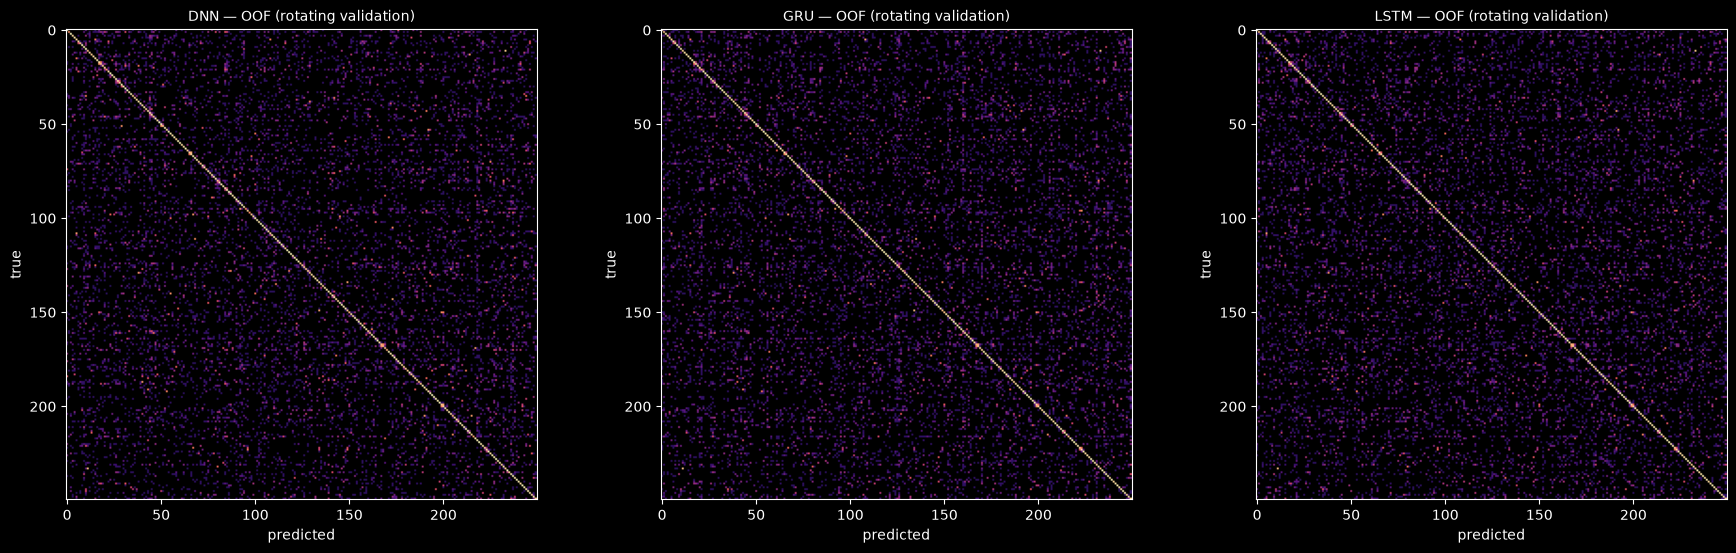

In [7]:
# =====
# OOF per-class accuracy + confusion matrix, per architecture
# =====
oof_labels = train_split["label"].to_numpy()
oof_metrics = {}
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(6 * len(ARCHITECTURES), 5.5))
for ax, arch in zip(axes, ARCHITECTURES):
    preds = oof_probs[arch].argmax(-1)
    oof_metrics[arch] = summary_metrics(oof_labels, preds, N_CLASSES)
    cm = compute_confusion(oof_labels, preds, N_CLASSES)
    R.plot_confusion(cm, f"{arch.upper()} — OOF (rotating validation)", ax)
fig.tight_layout()
fig.savefig(RUN_ROOT / "oof_confusion_matrices.png", dpi=110)
pd.DataFrame(oof_metrics).T


## 5. Final fit (one model per architecture, trained on all of train.csv)

The k-fold models in §4 each saw only `(K_FOLDS-1)/K_FOLDS` of `train.csv`. To
report a single held-out test number and a single set of landmark-importance
weights per architecture, one more model per architecture is fit on nearly
*all* of `train.csv` — a small stratified 5% internal carve-out
(`FINAL_VAL_FRACTION`) exists only to drive early stopping / the LR schedule;
it is never used to compute or report a metric.

In [8]:
# =====
# Final fit: one model per architecture, trained on (nearly) all of train.csv
# =====
tr_idx_final, val_idx_final = train_test_split(
    np.arange(len(train_split)), test_size=FINAL_VAL_FRACTION,
    stratify=train_split["label"], random_state=SEED,
)
print(f"final fit: {len(tr_idx_final)} train / {len(val_idx_final)} internal-val "
      f"(early-stopping signal only — never a reported metric)")

final_models = {}
for arch in ARCHITECTURES:
    ckpt = RUN_ROOT / arch / "final.pt"
    tr_loader = make_fold_loader(train_data, train_off, train_labels, tr_idx_final, HYP["batch_size"], True, SEED)
    va_loader = make_fold_loader(train_data, train_off, train_labels, val_idx_final, HYP["batch_size"], False, SEED)
    bar = tqdm(total=HYP["epochs"], desc=f"{arch} · final fit", dynamic_ncols=True)
    model, history, best_val_acc, best_state = train_fold(
        arch=arch, model_fn=lambda a=arch: make_model(a), train_loader=tr_loader, val_loader=va_loader,
        hyp=HYP, device=DEVICE, ckpt_path=ckpt, bar=bar, bar_prefix="final",
    )
    bar.close()
    model.load_state_dict(best_state)
    model.eval()
    final_models[arch] = model
    print(f"{arch}: final fit best internal-val acc {best_val_acc:.4f}")


final fit: 71801 train / 3780 internal-val (early-stopping signal only — never a reported metric)


dnn · final fit:   0%|          | 0/40 [00:00<?, ?it/s]

dnn: final fit best internal-val acc 0.7098


gru · final fit:   0%|          | 0/40 [00:00<?, ?it/s]

gru: final fit best internal-val acc 0.6796


lstm · final fit:   0%|          | 0/40 [00:00<?, ?it/s]

lstm: final fit best internal-val acc 0.7050


## 6. Held-out test-set evaluation (final models, ONE pass each)

`GISLR_Stratified`'s `test.csv` is the canonical held-out test set (README §
"Canonical evaluation") — each final model from §5 is scored on it exactly
once. This is the number to compare against the canonical GISLR leaderboard's
own test-set accuracy (`README.md` "Model registry"), keeping in mind this
track uses a different feature pipeline and the full landmark set, not the
ME-126 subset.

,overall_accuracy,macro_accuracy,median_class_accuracy,n_classes_below_50pct
dnn,0.710150,0.707146,0.750000,33.0
gru,0.679562,0.677206,0.688312,32.0
lstm,0.705493,0.703448,0.717183,16.0


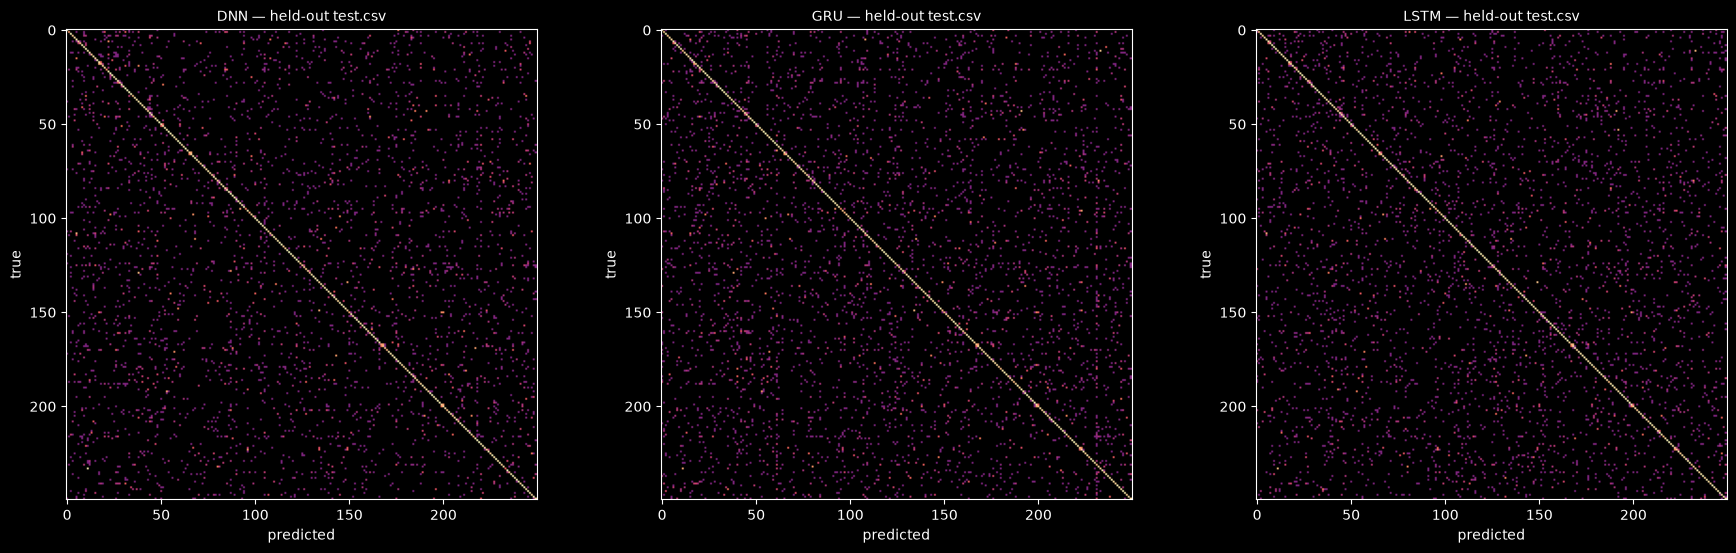

In [9]:
# =====
# ONE evaluation pass per final model, on the untouched canonical test.csv
# =====
test_data, test_off, test_labels_arr = load_split_arrays(te_data_path, te_off_path, test_split)

test_metrics = {}
test_results = {}
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(6 * len(ARCHITECTURES), 5.5))
for ax, arch in zip(axes, ARCHITECTURES):
    loader = make_row_tracked_loader(
        test_data, test_off, test_labels_arr, np.arange(len(test_split)), HYP["batch_size"]
    )
    rows, probs, ret_labels = predict_probs_indexed(final_models[arch], arch, loader, DEVICE)
    order = np.argsort(rows)
    preds, labels_ordered, probs_ordered = probs[order].argmax(-1), ret_labels[order], probs[order]

    test_metrics[arch] = summary_metrics(labels_ordered, preds, N_CLASSES)
    test_results[arch] = dict(preds=preds, labels=labels_ordered, probs=probs_ordered)
    np.savez(RUN_ROOT / arch / "test_predictions.npz", preds=preds, labels=labels_ordered, probs=probs_ordered)

    cm = compute_confusion(labels_ordered, preds, N_CLASSES)
    R.plot_confusion(cm, f"{arch.upper()} — held-out test.csv", ax)
fig.tight_layout()
fig.savefig(RUN_ROOT / "test_confusion_matrices.png", dpi=110)
pd.DataFrame(test_metrics).T


## 7. Landmark importance & ranking score

Three signals per landmark, per final model (`sb.recognize.interp.importance`):

1. **Attention gate** — the learned `LandmarkAttention` weight itself
   (structural, free, identical mechanism for all three architectures).
2. **Gradient×input saliency** — mean `|∂(true-class score)/∂landmark ×
   landmark|` over a fixed seeded sample of `IMPORTANCE_SAMPLE_SIZE` training
   videos (behavioral).
3. **Permutation importance** — video-accuracy drop from replacing one
   landmark's channel block across that same sample (most faithful, most
   expensive: one forward pass per landmark).

`ranking_score` averages each metric's normalized rank (0–1) — rank-averaging
because the three are on incomparable scales (a sigmoid in (0,1), a saliency
magnitude, an accuracy delta). Region grouping (Face / Pose / Left hand /
Right hand) is `sb.core.schema.GROUPS`, the same row layout the rest of the
repo uses.

In [10]:
# =====
# Attention / saliency / permutation importance -> combined ranking, per architecture
# =====
rng = np.random.default_rng(SEED)
sample_size = min(IMPORTANCE_SAMPLE_SIZE, len(train_split))
sample_rows = rng.choice(np.arange(len(train_split)), size=sample_size, replace=False)
sample_loader = make_fold_loader(
    train_data, train_off, train_labels, sample_rows, batch_size=sample_size, shuffle=False, seed=SEED
)
sample_feats, sample_lengths, sample_labels_t = next(iter(sample_loader))
print(f"importance sample: {sample_size} training videos (seed {SEED})")

rankings = {}
for arch in ARCHITECTURES:
    model = final_models[arch]
    aw = IMP.attention_weights(model)
    sal = IMP.gradient_saliency(model, arch, sample_feats, sample_lengths, sample_labels_t, DEVICE)
    baseline_acc, perm_drop = IMP.permutation_importance(
        model, arch, sample_feats, sample_lengths, sample_labels_t, DEVICE, seed=SEED
    )
    ranking = IMP.combine_ranking(
        {"attention": aw, "gradient_saliency": sal, "permutation_drop": perm_drop}
    )
    rankings[arch] = ranking
    ranking.to_csv(RUN_ROOT / arch / "assets" / "landmark_ranking.csv", index=False)
    print(f"{arch}: importance-sample baseline video-acc {baseline_acc:.4f}")

rankings["gru"].head(10)


importance sample: 400 training videos (seed 42)
dnn: importance-sample baseline video-acc 0.7525
gru: importance-sample baseline video-acc 0.8575
lstm: importance-sample baseline video-acc 0.9425


,landmark,region,attention,attention_rank,gradient_saliency,gradient_saliency_rank,permutation_drop,permutation_drop_rank,ranking_score
0,530,right_hand,0.994648,1.000000,0.029934,1.000000,0.3200,1.000000,1.000000
1,476,left_hand,0.993518,0.998155,0.021988,0.994465,0.2525,0.998155,0.996925
2,534,right_hand,0.991061,0.996310,0.022840,0.998155,0.2100,0.996310,0.996925
3,526,right_hand,0.989923,0.994465,0.022644,0.996310,0.1850,0.992620,0.994465
4,480,left_hand,0.989527,0.992620,0.016387,0.988930,0.2100,0.994465,0.992005
5,542,right_hand,0.981827,0.985240,0.018495,0.990775,0.1550,0.990775,0.988930
6,538,right_hand,0.987902,0.990775,0.018761,0.992620,0.1225,0.981550,0.988315
7,472,left_hand,0.981459,0.983395,0.014998,0.985240,0.1525,0.988930,0.985855
8,488,left_hand,0.984356,0.987085,0.014236,0.983395,0.1350,0.985240,0.985240
9,529,right_hand,0.975920,0.981550,0.014181,0.981550,0.1225,0.983395,0.982165


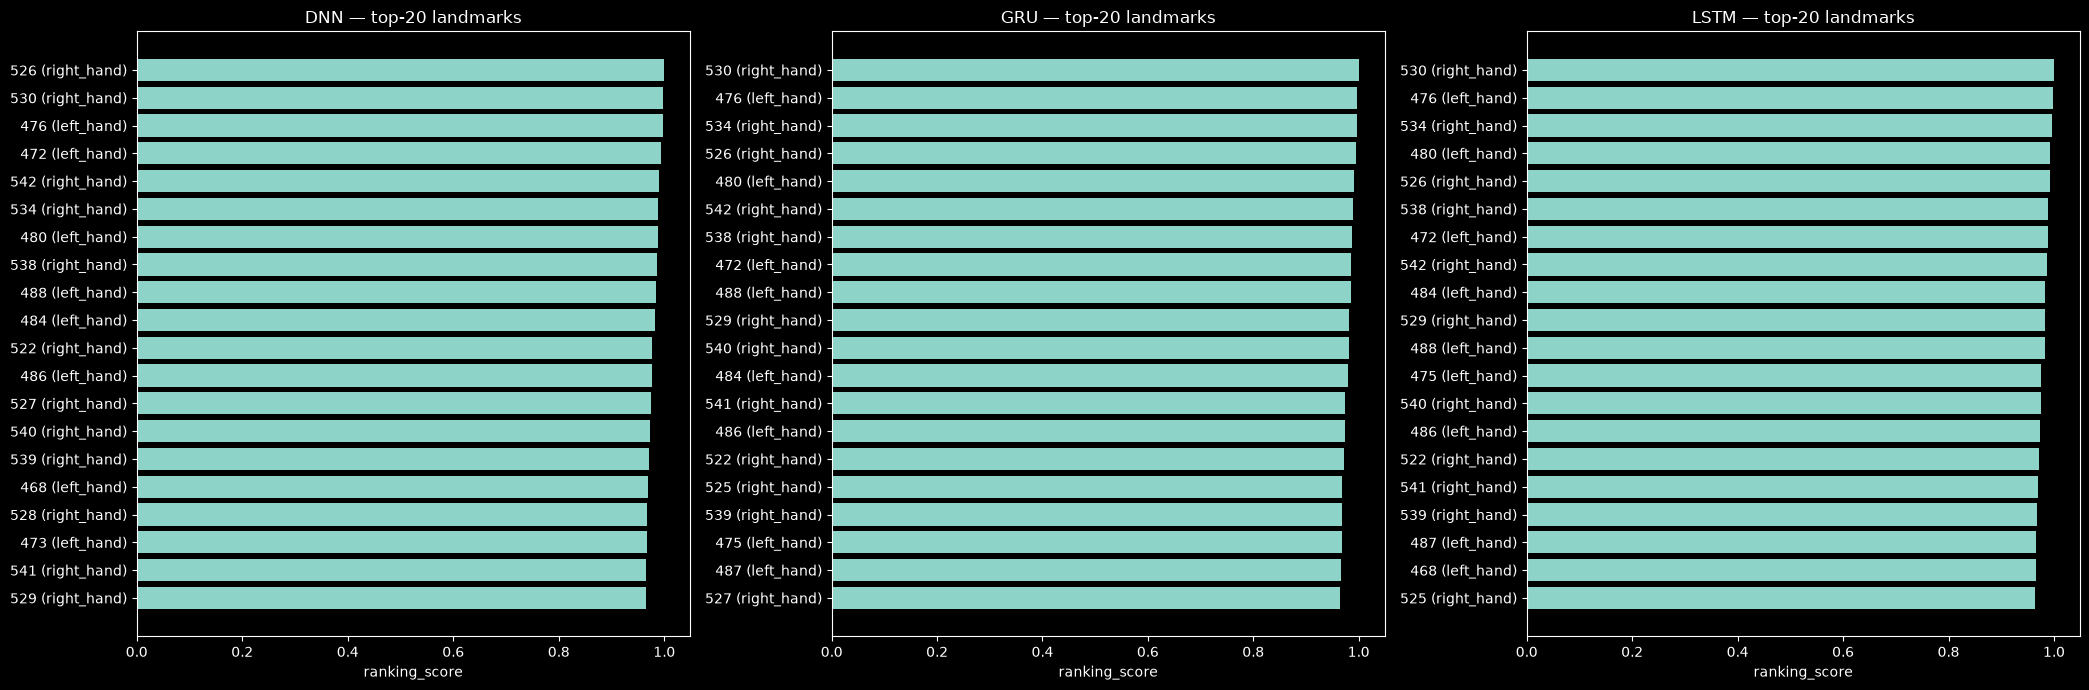

In [11]:
# =====
# Top-20 landmarks per architecture (bar chart)
# =====
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(7 * len(ARCHITECTURES), 7))
for ax, arch in zip(axes, ARCHITECTURES):
    top = rankings[arch].head(20).iloc[::-1]
    ax.barh(top["landmark"].astype(str) + " (" + top["region"] + ")", top["ranking_score"])
    ax.set_title(f"{arch.upper()} — top-20 landmarks")
    ax.set_xlabel("ranking_score")
fig.tight_layout()
fig.savefig(RUN_ROOT / "top20_landmarks.png", dpi=110)


,dnn,gru,lstm
region,,,
right_hand,0.957799,0.965062,0.948457
left_hand,0.950214,0.953084,0.956598
pose,0.754109,0.716967,0.728615
face,0.441338,0.443502,0.443268


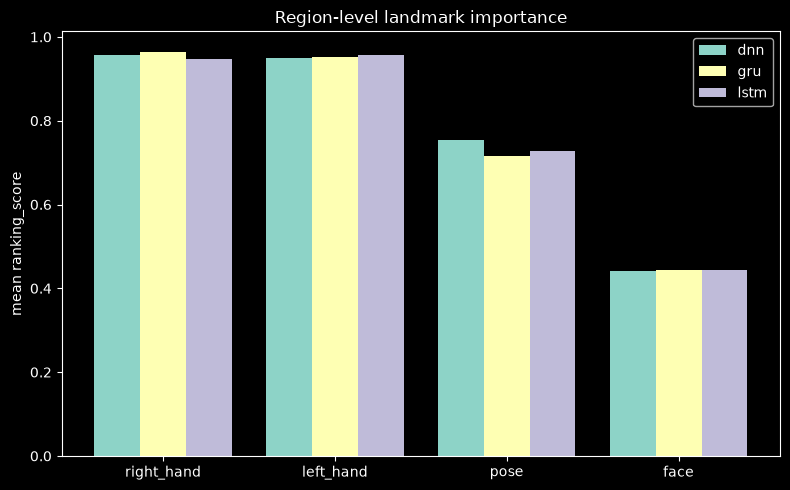

In [12]:
# =====
# Region-level importance (Face / Pose / Left hand / Right hand)
# =====
region_tables = {arch: IMP.region_summary(rankings[arch]) for arch in ARCHITECTURES}
regions = region_tables["gru"].index.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.8 / len(ARCHITECTURES)
x = np.arange(len(regions))
for i, arch in enumerate(ARCHITECTURES):
    scores = region_tables[arch].reindex(regions)["ranking_score"]
    ax.bar(x + i * width, scores, width, label=arch)
ax.set_xticks(x + width * (len(ARCHITECTURES) - 1) / 2)
ax.set_xticklabels(regions)
ax.set_ylabel("mean ranking_score")
ax.set_title("Region-level landmark importance")
ax.legend()
fig.tight_layout()
fig.savefig(RUN_ROOT / "region_ranking.png", dpi=110)

pd.concat({arch: t["ranking_score"] for arch, t in region_tables.items()}, axis=1)


## 8. Cross-architecture comparison

Two non-redundant checks beyond raw accuracy: **macro/median per-class
accuracy** (does the model win by acing a few common classes, or broadly?)
and **cross-architecture ranking agreement** (Spearman ρ between each pair of
architectures' `ranking_score` over all 543 landmarks) — the closer to 1, the
more the three architectures independently converge on the same landmarks
mattering, which is the strongest evidence a landmark's importance is a
property of the *signs*, not an artifact of one architecture's inductive
bias.

In [13]:
# =====
# Cross-architecture ranking-score correlation (Spearman)
# =====
corr = pd.DataFrame(index=ARCHITECTURES, columns=ARCHITECTURES, dtype=float)
for a in ARCHITECTURES:
    a_sorted = rankings[a].sort_values("landmark")["ranking_score"].to_numpy()
    for b in ARCHITECTURES:
        b_sorted = rankings[b].sort_values("landmark")["ranking_score"].to_numpy()
        corr.loc[a, b] = spearmanr(a_sorted, b_sorted).statistic
corr


,dnn,gru,lstm
dnn,1.000000,0.822717,0.819440
gru,0.822717,1.000000,0.846762
lstm,0.819440,0.846762,1.000000


In [14]:
# =====
# Final comparison table + save
# =====
comparison = pd.DataFrame(test_metrics).T
comparison["n_params"] = pd.Series(n_params)
comparison["oof_overall_accuracy"] = pd.Series({a: oof_metrics[a]["overall_accuracy"] for a in ARCHITECTURES})
comparison.to_csv(RUN_ROOT / "comparison.csv")
comparison


,overall_accuracy,macro_accuracy,median_class_accuracy,n_classes_below_50pct,n_params,oof_overall_accuracy
dnn,0.710150,0.707146,0.750000,33.0,6309021,0.674164
gru,0.679562,0.677206,0.688312,32.0,3850141,0.686800
lstm,0.705493,0.703448,0.717183,16.0,4178845,0.681759


## 9. Summary & artifact index

All artifacts referenced above live under `data/cache/gislr/interp_runs/`
(gitignored, per the data-placement policy) — nothing here writes to
`registry/`. Re-running this notebook top-to-bottom after it has completed
once costs only the read of each cached/checkpointed artifact: caches,
`folds.json`, every `fold<k>.pt`/`final.pt`, and every `oof_predictions.npz`
are all skip-if-exists.

Follow-ups belong in `TODO.md` §3 (Data-Driven Landmark Importance), not this
cell — this notebook's own title cell records the design decisions it made
that a follow-up might revisit (rank-averaging formula, permutation's
whole-sequence-swap approximation, the 5% final-fit internal-val carve-out).

In [15]:
# =====
# Artifact index
# =====
print(f"run root: {RUN_ROOT}\n")
for path in sorted(RUN_ROOT.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(RUN_ROOT)}  ({path.stat().st_size / 1e3:.1f} KB)")


run root: C:\Users\user2\repository\data\cache\gislr\interp_runs

  comparison.csv  (0.4 KB)
  dnn\assets\landmark_ranking.csv  (66.4 KB)
  dnn\final.pt  (100971.8 KB)
  dnn\fold0.pt  (100971.5 KB)
  dnn\fold1.pt  (100971.5 KB)
  dnn\fold2.pt  (100971.5 KB)
  dnn\fold3.pt  (100971.5 KB)
  dnn\fold4.pt  (100971.8 KB)
  dnn\oof_predictions.npz  (76186.2 KB)
  dnn\test_predictions.npz  (19199.1 KB)
  folds.json  (226.8 KB)
  gru\assets\landmark_ranking.csv  (65.8 KB)
  gru\final.pt  (61631.2 KB)
  gru\fold0.pt  (61630.8 KB)
  gru\fold1.pt  (61630.8 KB)
  gru\fold2.pt  (61630.8 KB)
  gru\fold3.pt  (61630.6 KB)
  gru\fold4.pt  (61630.8 KB)
  gru\oof_predictions.npz  (76186.2 KB)
  gru\test_predictions.npz  (19199.1 KB)
  lstm\assets\landmark_ranking.csv  (65.2 KB)
  lstm\final.pt  (66889.9 KB)
  lstm\fold0.pt  (66890.1 KB)
  lstm\fold1.pt  (66890.1 KB)
  lstm\fold2.pt  (66890.1 KB)
  lstm\fold3.pt  (66890.1 KB)
  lstm\fold4.pt  (66890.4 KB)
  lstm\oof_predictions.npz  (76186.2 KB)
  lstm\te